In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('train_data.csv')
df.head()

,Index,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,0,0,0.450397,0.504034,0.506986,0.594640,0.594640,0.998906,0.797293,0.809239,...,0.780554,0.004919,0.623634,0.594641,0.838869,0.279036,0.026788,0.565144,1,0.032464
1,1,0,0.530005,0.572885,0.574763,0.605695,0.605558,0.999058,0.797512,0.809399,...,0.819963,0.005968,0.624171,0.605690,0.841869,0.279040,0.026801,0.565205,1,0.032442
2,2,0,0.571150,0.620148,0.624177,0.612275,0.612282,0.999163,0.797654,0.809533,...,0.839128,0.006022,0.625306,0.612271,0.843294,0.278927,0.026816,0.565276,1,0.033034
3,3,0,0.483401,0.556694,0.536164,0.602445,0.602445,0.999035,0.797458,0.809380,...,0.806477,0.002177,0.621610,0.602444,0.841891,0.293391,0.027063,0.566190,1,0.015406
4,4,0,0.510359,0.537287,0.552546,0.600023,0.600023,0.999009,0.797406,0.809313,...,0.799277,0.001124,0.623993,0.600019,0.840313,0.279878,0.026880,0.565549,1,0.028858



## 1. Data Loading

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5807 entries, 0 to 5806
Data columns (total 97 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Index                                                     5807 non-null   int64  
 1   Bankrupt?                                                 5807 non-null   int64  
 2    ROA(C) before interest and depreciation before interest  5807 non-null   float64
 3    ROA(A) before interest and % after tax                   5807 non-null   float64
 4    ROA(B) before interest and depreciation after tax        5807 non-null   float64
 5    Operating Gross Margin                                   5807 non-null   float64
 6    Realized Sales Gross Margin                              5807 non-null   float64
 7    Operating Profit Rate                                    5807 non-null   float64
 8    Pre-tax net Inter

In [4]:
print(df.describe())

             Index    Bankrupt?  \
count  5807.000000  5807.000000   
mean   2903.000000     0.034097   
std    1676.480838     0.181493   
min       0.000000     0.000000   
25%    1451.500000     0.000000   
50%    2903.000000     0.000000   
75%    4354.500000     0.000000   
max    5806.000000     1.000000   

        ROA(C) before interest and depreciation before interest  \
count                                        5807.000000          
mean                                            0.505416          
std                                             0.060808          
min                                             0.000000          
25%                                             0.476673          
50%                                             0.503096          
75%                                             0.535417          
max                                             1.000000          

        ROA(A) before interest and % after tax  \
count                         

In [5]:
print(df.shape)
print(df["Bankrupt?"].value_counts())

(5807, 97)
Bankrupt?
0    5609
1     198
Name: count, dtype: int64



## 2. Understanding the Class Imbalance (Target)

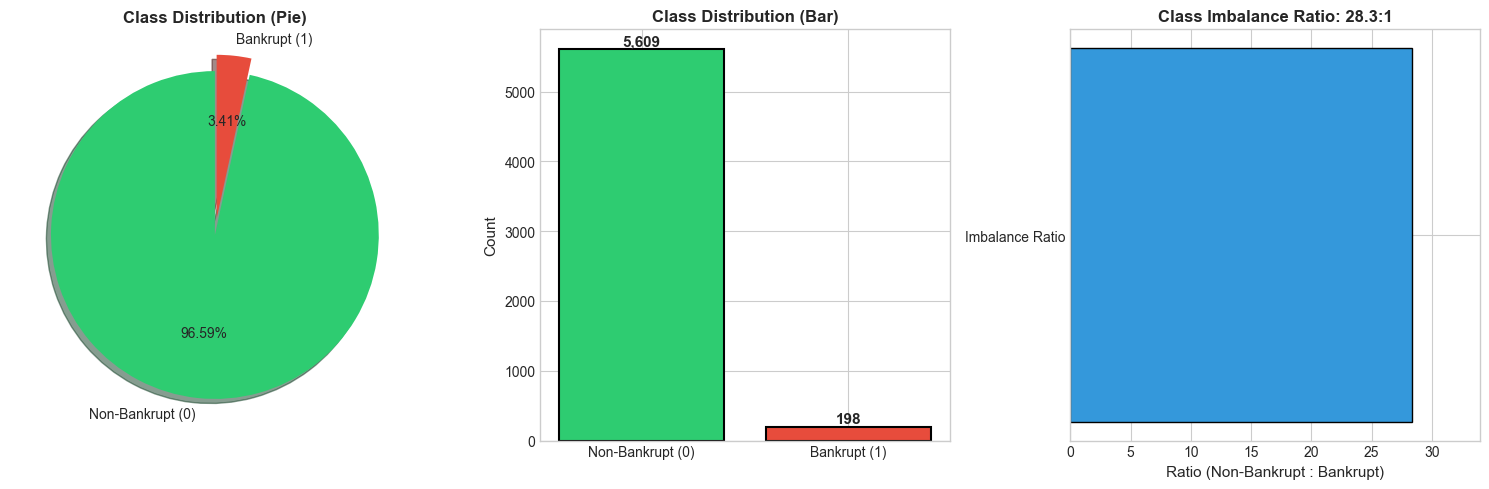

Total Samples: 5,807
Non-Bankrupt (0): 5,609 (96.59%)
Bankrupt (1): 198 (3.41%)
Imbalance Ratio: 28.3:1


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

bankrupt_counts = df["Bankrupt?"].value_counts()
labels = ['Non-Bankrupt (0)', 'Bankrupt (1)']
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)

axes[0].pie(bankrupt_counts, explode=explode, labels=labels, colors=colors,
            autopct='%1.2f%%', shadow=True, startangle=90)
axes[0].set_title('Class Distribution (Pie)', fontsize=12, fontweight='bold')

bars = axes[1].bar(labels, bankrupt_counts, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Class Distribution (Bar)', fontsize=12, fontweight='bold')
for bar, count in zip(bars, bankrupt_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                 f'{count:,}', ha='center', fontsize=11, fontweight='bold')

imbalance_ratio = bankrupt_counts[0] / bankrupt_counts[1]
axes[2].barh(['Imbalance Ratio'], [imbalance_ratio], color='#3498db', edgecolor='black')
axes[2].set_xlabel('Ratio (Non-Bankrupt : Bankrupt)', fontsize=11)
axes[2].set_title(f'Class Imbalance Ratio: {imbalance_ratio:.1f}:1', fontsize=12, fontweight='bold')
axes[2].set_xlim(0, imbalance_ratio * 1.2)

plt.tight_layout()
plt.show()

print(f"Total Samples: {len(df):,}")
print(f"Non-Bankrupt (0): {bankrupt_counts[0]:,} ({bankrupt_counts[0]/len(df)*100:.2f}%)")
print(f"Bankrupt (1): {bankrupt_counts[1]:,} ({bankrupt_counts[1]/len(df)*100:.2f}%)")
print(f"Imbalance Ratio: {imbalance_ratio:.1f}:1")


## 3. Finding Misiing Values

In [26]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

print(f"Total Features: {df.shape[1]}")
print(f"Features with Missing Values: {(missing > 0).sum()}")
print(f"Total Missing Values: {missing.sum()}")

missing_df = pd.DataFrame({
    'Missing Count': missing[missing > 0],
    'Missing %': missing_pct[missing_pct > 0]
}).sort_values('Missing Count', ascending=False)
X_check = df.drop(columns=['Index', 'Bankrupt?'])
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

print(df.dtypes.value_counts())

Total Features: 97
Features with Missing Values: 0
Total Missing Values: 0
Duplicate rows: 0
float64    93
int64       4
Name: count, dtype: int64



## 4. Outliers

In [27]:
X_features = df.drop(columns=['Index', 'Bankrupt?'])
feature_names = X_features.columns.tolist()
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

outlier_counts = X_features.apply(count_outliers_iqr)
outlier_pct = (outlier_counts / len(df)) * 100

outlier_df = pd.DataFrame({
    'Outlier Count': outlier_counts,
    'Outlier %': outlier_pct
}).sort_values('Outlier %', ascending=False)

print("OUTLIER ANALYSIS (Using Interquartile Range Method)")
print(f"Features with >10% outliers: {(outlier_pct > 10).sum()}")
print(f"Features with >20% outliers: {(outlier_pct > 20).sum()}")
print(f"Features with >30% outliers: {(outlier_pct > 30).sum()}")

print("\nTop 20 Features by Outlier Percentage:")
print(outlier_df.head(20).round(2))

OUTLIER ANALYSIS (Using Interquartile Range Method)
Features with >10% outliers: 30
Features with >20% outliers: 5
Features with >30% outliers: 0

Top 20 Features by Outlier Percentage:
                                                    Outlier Count  Outlier %
Degree of Financial Leverage (DFL)                           1274      21.94
Fixed Assets Turnover Frequency                              1215      20.92
Interest Coverage Ratio (Interest expense to EBIT)           1208      20.80
Current Asset Turnover Rate                                  1188      20.46
Total Asset Growth Rate                                      1188      20.46
Interest Expense Ratio                                       1153      19.86
Cash Flow to Liability                                       1026      17.67
No-credit Interval                                            961      16.55
Non-industry income and expenditure/revenue                   941      16.20
Cash Flow to Sales                          

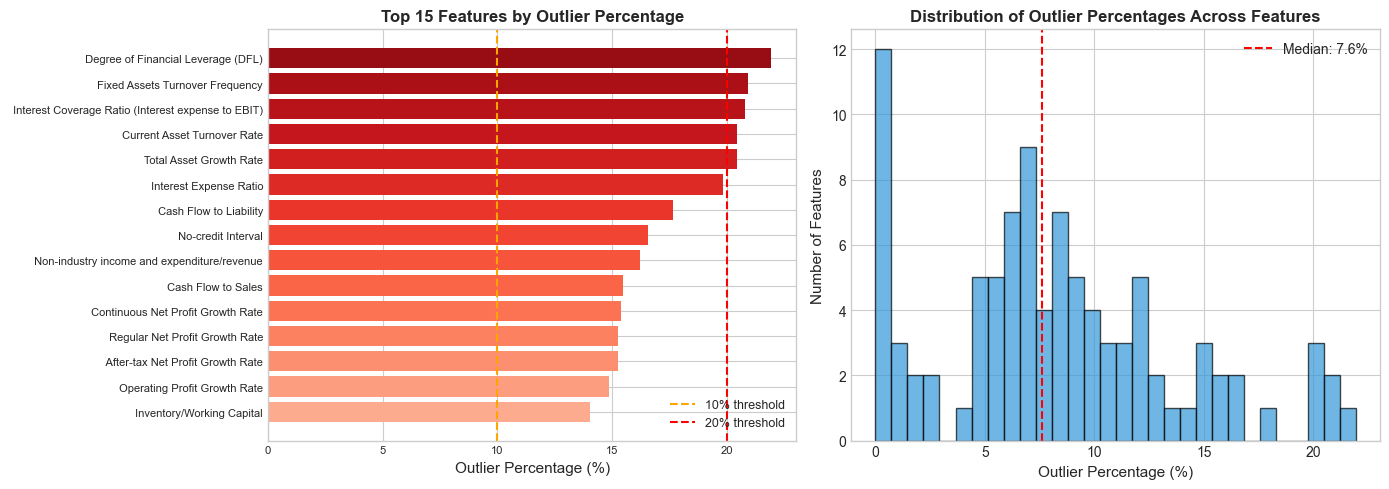

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_outlier_features = outlier_df.head(15)
ax1 = axes[0]
bars = ax1.barh(top_outlier_features.index[::-1], top_outlier_features['Outlier %'].values[::-1], 
                color=plt.cm.Reds(np.linspace(0.3, 0.9, 15)))
ax1.set_xlabel('Outlier Percentage (%)', fontsize=11)
ax1.set_title('Top 15 Features by Outlier Percentage', fontsize=12, fontweight='bold')
ax1.axvline(x=10, color='orange', linestyle='--', label='10% threshold')
ax1.axvline(x=20, color='red', linestyle='--', label='20% threshold')
ax1.legend(fontsize=9)
ax1.tick_params(labelsize=8)

ax2 = axes[1]
ax2.hist(outlier_pct, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Outlier Percentage (%)', fontsize=11)
ax2.set_ylabel('Number of Features', fontsize=11)
ax2.set_title('Distribution of Outlier Percentages Across Features', fontsize=12, fontweight='bold')
ax2.axvline(x=outlier_pct.median(), color='red', linestyle='--', 
            label=f'Median: {outlier_pct.median():.1f}%')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

Bar chart (in red) ranking features by outlier percentage.
Histogram (in blue) showing distribution of outlier percentages across all features.


## 5. Correlation

In [28]:
target_correlation = X_features.apply(lambda x: x.corr(df['Bankrupt?']))
target_correlation = target_correlation.sort_values(key=abs, ascending=False)

print("CORRELATION WITH OUR TARGET (Bankrupt?)")
print("\nTop 20 Features Most Correlated with Bankruptcy:")
print(target_correlation.head(20).round(4))

print("\nBottom 10 Features Least Correlated with Bankruptcy:")
print(target_correlation.tail(10).round(4))

CORRELATION WITH OUR TARGET (Bankrupt?)

Top 20 Features Most Correlated with Bankruptcy:
Net Income to Total Assets                                -0.3195
ROA(A) before interest and % after tax                    -0.2794
ROA(B) before interest and depreciation after tax         -0.2694
ROA(C) before interest and depreciation before interest   -0.2583
Net worth/Assets                                          -0.2559
Debt ratio %                                               0.2559
Retained Earnings to Total Assets                         -0.2452
Persistent EPS in the Last Four Seasons                   -0.2138
Net profit before tax/Paid-in capital                     -0.2028
Per Share Net profit before tax (Yuan ¥)                  -0.1965
Working Capital to Total Assets                           -0.1957
Current Liability to Assets                                0.1952
Borrowing dependency                                       0.1941
Net Income to Stockholder's Equity                  

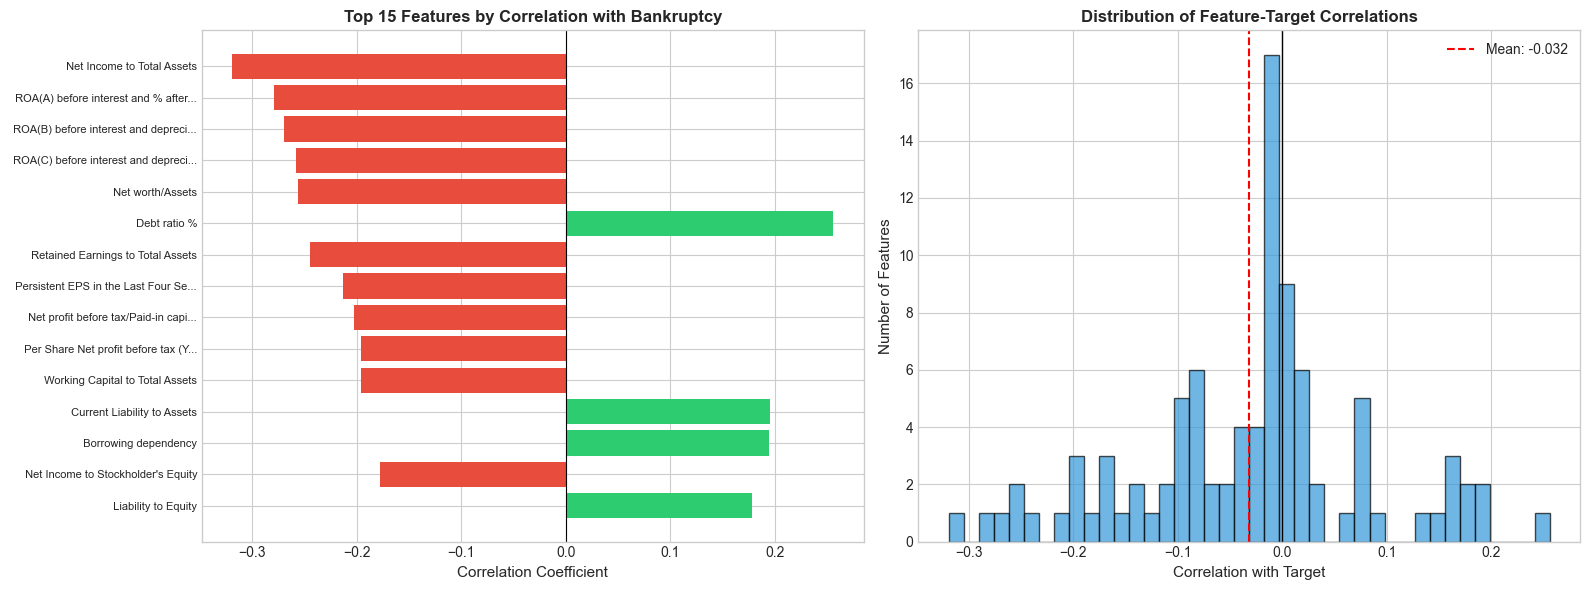

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_corr = target_correlation.head(15)
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in top_corr.values]

ax1 = axes[0]
ax1.barh(range(len(top_corr)), top_corr.values, color=colors)
ax1.set_yticks(range(len(top_corr)))
ax1.set_yticklabels([f'{name[:35]}...' if len(name) > 35 else name for name in top_corr.index], fontsize=8)
ax1.set_xlabel('Correlation Coefficient', fontsize=11)
ax1.set_title('Top 15 Features by Correlation with Bankruptcy', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.invert_yaxis()

ax2 = axes[1]
ax2.hist(target_correlation, bins=40, color='#3498db', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Correlation with Target', fontsize=11)
ax2.set_ylabel('Number of Features', fontsize=11)
ax2.set_title('Distribution of Feature-Target Correlations', fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.axvline(x=target_correlation.mean(), color='red', linestyle='--', 
            label=f'Mean: {target_correlation.mean():.3f}')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

Bar chart ranking features by outlier percentage; 

Histogram showing distribution of outlier percentages across all features.

In [ ]:
top_corr_features = target_correlation.head(20).index.tolist()
corr_matrix = X_features[top_corr_features].corr()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i][:30],
                'Feature 2': corr_matrix.columns[j][:30],
                'Correlation': corr_matrix.iloc[i, j]
            })

print("HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.8)")
print(f"Found {len(high_corr_pairs)} highly correlated pairs among top 20 features\n")

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(high_corr_df.head(15).to_string(index=False))

HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.8)
Found 18 highly correlated pairs among top 20 features

                     Feature 1                      Feature 2  Correlation
              Net worth/Assets                   Debt ratio %    -1.000000
       Net Value Per Share (A)        Net Value Per Share (C)     0.999820
       Net Value Per Share (A)        Net Value Per Share (B)     0.999256
       Net Value Per Share (B)        Net Value Per Share (C)     0.999076
 ROA(B) before interest and de  ROA(C) before interest and de     0.986581
    Net Income to Total Assets  ROA(A) before interest and %      0.972268
 Net profit before tax/Paid-in  Per Share Net profit before t     0.960669
 Persistent EPS in the Last Fo  Net profit before tax/Paid-in     0.957085
 ROA(A) before interest and %   ROA(B) before interest and de     0.954590
 Persistent EPS in the Last Fo  Per Share Net profit before t     0.954129
          Borrowing dependency            Liability to Equity     0.953580


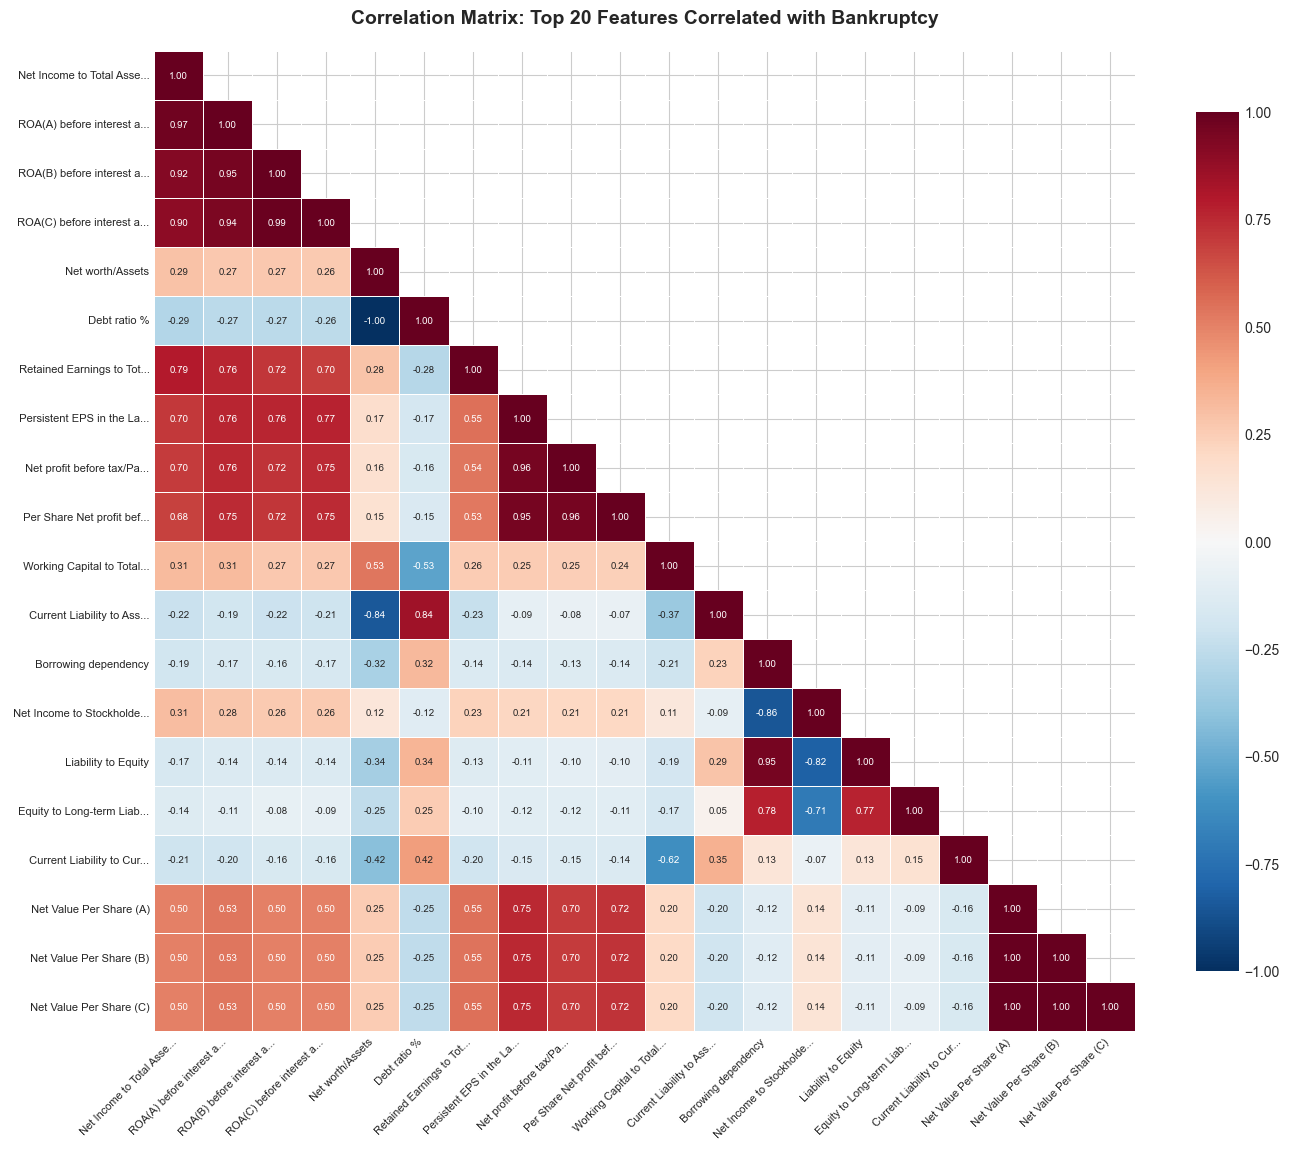

In [15]:
plt.figure(figsize=(14, 12))
short_names = [name[:25] + '...' if len(name) > 25 else name for name in top_corr_features]

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            xticklabels=short_names, yticklabels=short_names,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})

plt.title('Correlation Matrix: Top 20 Features Correlated with Bankruptcy', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

Heatmap showing pairwise correlations among the top 20 most predictive features, revealing redundancy and multicollinearity.


## 6. Skewness

In [17]:
from scipy import stats
skewness = X_features.apply(lambda x: stats.skew(x.dropna()))
kurtosis = X_features.apply(lambda x: stats.kurtosis(x.dropna()))

skew_kurt_df = pd.DataFrame({
    'Skewness': skewness,
    'Abs_Skewness': abs(skewness)
}).sort_values('Abs_Skewness', ascending=False)
print("SKEWNESS")
print(f"\nHighly Skewed Features (|skew| > 2): {(abs(skewness) > 2).sum()}")
print(f"Moderately Skewed Features (1 < |skew| <= 2): {((abs(skewness) > 1) & (abs(skewness) <= 2)).sum()}")
print(f"Approximately Symmetric (|skew| <= 1): {(abs(skewness) <= 1).sum()}")
print("\nTop 3 Most Skewed Features:")
print(skew_kurt_df.drop('Abs_Skewness', axis=1).head(3).round(3))

SKEWNESS

Highly Skewed Features (|skew| > 2): 74
Moderately Skewed Features (1 < |skew| <= 2): 8
Approximately Symmetric (|skew| <= 1): 12

Top 3 Most Skewed Features:
                        Skewness
Revenue per person        76.184
Current Ratio             76.184
Fixed Assets to Assets    76.184


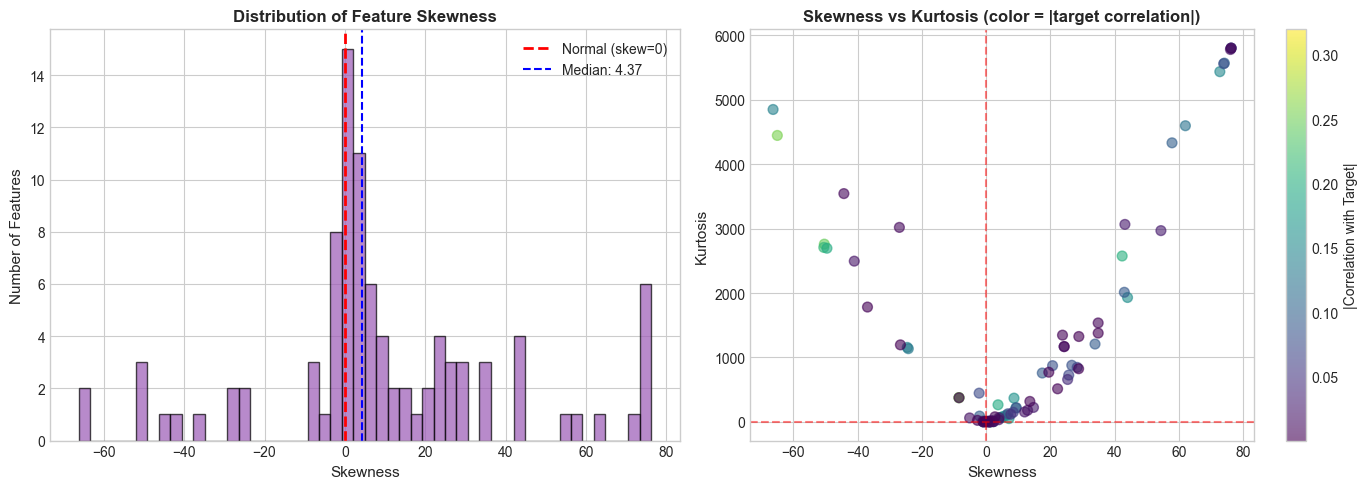

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1 = axes[0]
ax1.hist(skewness, bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Skewness', fontsize=11)
ax1.set_ylabel('Number of Features', fontsize=11)
ax1.set_title('Distribution of Feature Skewness', fontsize=12, fontweight='bold')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Normal (skew=0)')
ax1.axvline(x=skewness.median(), color='blue', linestyle='--', 
            label=f'Median: {skewness.median():.2f}')
ax1.legend(fontsize=10)
ax2 = axes[1]
scatter = ax2.scatter(skewness, kurtosis, c=abs(target_correlation), 
                      cmap='viridis', alpha=0.6, s=50)
ax2.set_xlabel('Skewness', fontsize=11)
ax2.set_ylabel('Kurtosis', fontsize=11)
ax2.set_title('Skewness vs Kurtosis (color = |target correlation|)', 
              fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='red', linestyle='--', alpha=0.5)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.colorbar(scatter, ax=ax2, label='|Correlation with Target|')

plt.tight_layout()
plt.show()

Histogram shows feature skewness values,
Scatter plot of skewness vs kurtosis colored by target correlation.


## 7. PCA

In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_features)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("PCA ANALYSIS")
print("\nExplained Variance by Component:")
for i, (var, cum) in enumerate(zip(explained_var, cumulative_var)):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%) | Cumulative: {cum:.4f} ({cum*100:.2f}%)")

PCA ANALYSIS

Explained Variance by Component:
  PC1: 0.1345 (13.45%) | Cumulative: 0.1345 (13.45%)
  PC2: 0.0742 (7.42%) | Cumulative: 0.2086 (20.86%)
  PC3: 0.0527 (5.27%) | Cumulative: 0.2613 (26.13%)
  PC4: 0.0476 (4.76%) | Cumulative: 0.3089 (30.89%)
  PC5: 0.0427 (4.27%) | Cumulative: 0.3517 (35.17%)
  PC6: 0.0325 (3.25%) | Cumulative: 0.3842 (38.42%)
  PC7: 0.0311 (3.11%) | Cumulative: 0.4153 (41.53%)
  PC8: 0.0300 (3.00%) | Cumulative: 0.4453 (44.53%)
  PC9: 0.0281 (2.81%) | Cumulative: 0.4734 (47.34%)
  PC10: 0.0219 (2.19%) | Cumulative: 0.4953 (49.53%)


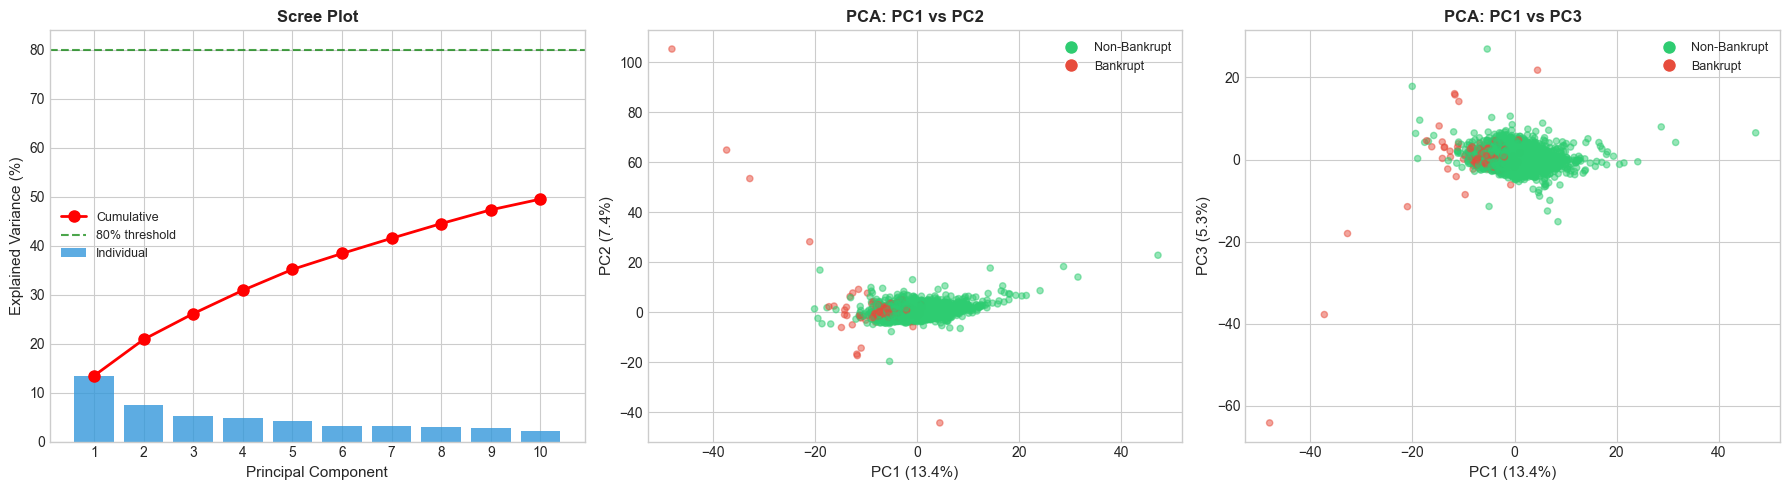

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax1 = axes[0]
x_pos = range(1, len(explained_var) + 1)
ax1.bar(x_pos, explained_var * 100, color='#3498db', alpha=0.8, label='Individual')
ax1.plot(x_pos, cumulative_var * 100, 'ro-', linewidth=2, markersize=8, label='Cumulative')
ax1.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% threshold')
ax1.set_xlabel('Principal Component', fontsize=11)
ax1.set_ylabel('Explained Variance (%)', fontsize=11)
ax1.set_title('Scree Plot', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_xticks(x_pos)
ax2 = axes[1]
colors = ['#2ecc71' if y == 0 else '#e74c3c' for y in df['Bankrupt?']]
scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.5, s=20)
ax2.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)', fontsize=11)
ax2.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)', fontsize=11)
ax2.set_title('PCA: PC1 vs PC2', fontsize=12, fontweight='bold')
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', 
                          markersize=10, label='Non-Bankrupt'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', 
                          markersize=10, label='Bankrupt')]
ax2.legend(handles=legend_elements, fontsize=9)
ax3 = axes[2]
ax3.scatter(X_pca[:, 0], X_pca[:, 2], c=colors, alpha=0.5, s=20)
ax3.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)', fontsize=11)
ax3.set_ylabel(f'PC3 ({explained_var[2]*100:.1f}%)', fontsize=11)
ax3.set_title('PCA: PC1 vs PC3', fontsize=12, fontweight='bold')
ax3.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.show()

Left: Scree plot of variance explained

Middle: PC1 vs PC2 scatter

Right: PC1 vs PC3 scatter (all showing class separation.)


## EDA Key Insights

In [23]:
print("EDA OVERVIEW")

print(f"""
DATASET OVERVIEW
   • Total Samples: {len(df):,}
   • Total Features: {len(feature_names)}
   • Target: Binary (Bankrupt: 0/1)

CLASS IMBALANCE
   • Non-Bankrupt: {(df['Bankrupt?']==0).sum():,} ({(df['Bankrupt?']==0).sum()/len(df)*100:.2f}%)
   • Bankrupt: {(df['Bankrupt?']==1).sum():,} ({(df['Bankrupt?']==1).sum()/len(df)*100:.2f}%)
   • Imbalance Ratio: {(df['Bankrupt?']==0).sum()/(df['Bankrupt?']==1).sum():.1f}:1

DATA QUALITY
   • Missing Values: {df.isnull().sum().sum()}
   • Duplicate Rows: {df.duplicated().sum()}
   • Features with >20% Outliers: {(outlier_pct > 20).sum()}

FEATURE INSIGHTS
   • Highly Skewed Features (|skew|>2): {(abs(skewness) > 2).sum()}
   • Strong Target Correlation (|r|>0.1): {(abs(target_correlation) > 0.1).sum()}

PCA INSIGHTS
   • PC1 explains {explained_var[0]*100:.1f}% of variance
   • Top 5 PCs explain {cumulative_var[4]*100:.1f}% of variance
   • Top 10 PCs explain {cumulative_var[9]*100:.1f}% of variance
""")

EDA OVERVIEW

DATASET OVERVIEW
   • Total Samples: 5,807
   • Total Features: 95
   • Target: Binary (Bankrupt: 0/1)

CLASS IMBALANCE
   • Non-Bankrupt: 5,609 (96.59%)
   • Bankrupt: 198 (3.41%)
   • Imbalance Ratio: 28.3:1

DATA QUALITY
   • Missing Values: 0
   • Duplicate Rows: 0
   • Features with >20% Outliers: 5

FEATURE INSIGHTS
   • Highly Skewed Features (|skew|>2): 74
   • Strong Target Correlation (|r|>0.1): 30

PCA INSIGHTS
   • PC1 explains 13.4% of variance
   • Top 5 PCs explain 35.2% of variance
   • Top 10 PCs explain 49.5% of variance



---
## Feature Reduction & Clustering

In [ ]:
y = df["Bankrupt?"]
index_col = df["Index"]

X = df.drop(columns=["Index", "Bankrupt?"])
print(X.shape, y.value_counts())

(5807, 95) Bankrupt?
0    5609
1     198
Name: count, dtype: int64


In [ ]:
var_thresh = VarianceThreshold(threshold=1e-5)
X_var = var_thresh.fit_transform(X)

selected_cols_step1 = X.columns[var_thresh.get_support()]
print("After variance filter:", X_var.shape)

After variance filter: (5807, 94)


In [ ]:
X_var_df = pd.DataFrame(X_var, columns=selected_cols_step1)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf.fit(X_var_df, y)
importances = pd.Series(rf.feature_importances_, index=X_var_df.columns)
importances = importances.sort_values(ascending=False)
TOP_K = 40 
top_features = importances.head(TOP_K).index.tolist()
print("Top features:", len(top_features))

Top features: 40


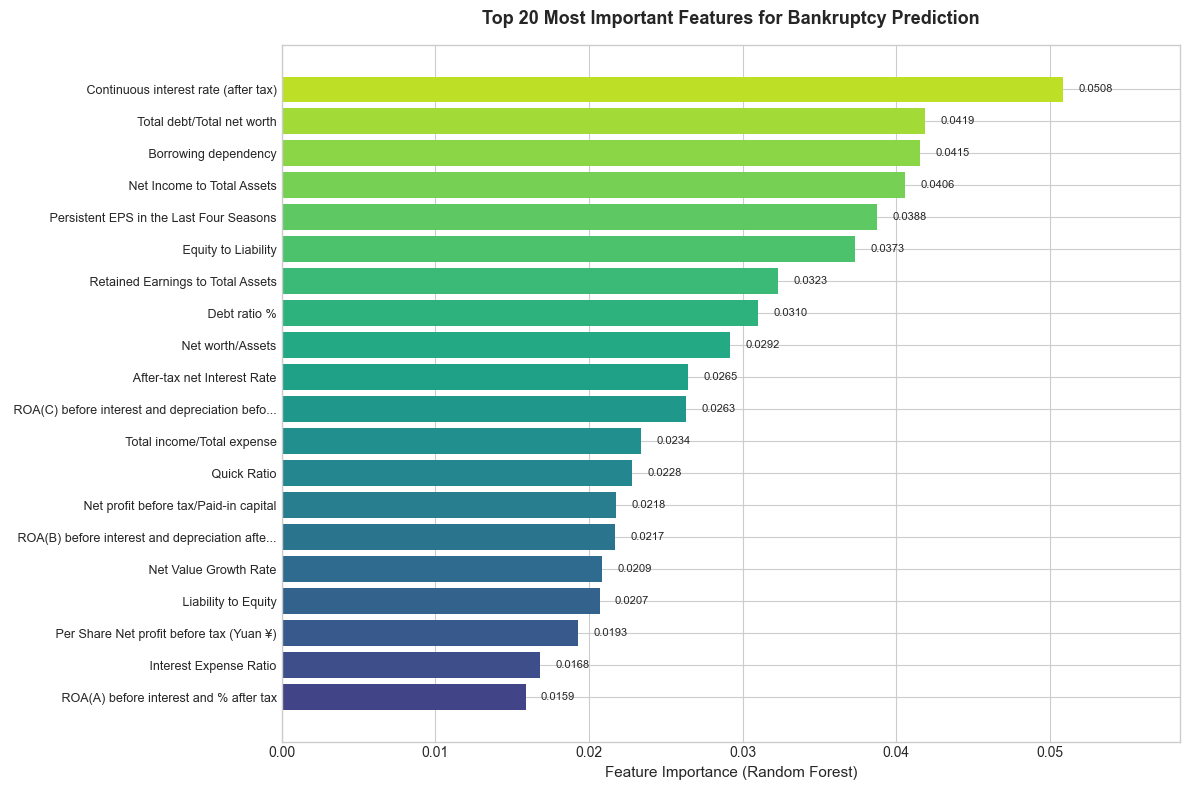


Top 20 features account for 57.9% of total importance
Top 40 features account for 77.5% of total importance


In [ ]:
top_20 = importances.head(20)
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(top_20)), top_20.values[::-1], 
               color=plt.cm.viridis(np.linspace(0.2, 0.9, len(top_20))))

short_names = [name[:45] + '...' if len(name) > 45 else name for name in top_20.index[::-1]]
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(short_names, fontsize=9)

for i, (bar, val) in enumerate(zip(bars, top_20.values[::-1])):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontsize=8)

ax.set_xlabel('Feature Importance (Random Forest)', fontsize=11)
ax.set_title('Top 20 Most Important Features for Bankruptcy Prediction', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, top_20.values[0] * 1.15)

plt.tight_layout()
plt.show()

print(f"\nTop 20 features account for {top_20.sum()/importances.sum()*100:.1f}% of total importance")
print(f"Top 40 features account for {importances.head(40).sum()/importances.sum()*100:.1f}% of total importance")

In [9]:
X_reduced = X_var_df[top_features].copy()
print("Reduced feature matrix:", X_reduced.shape)

Reduced feature matrix: (5807, 40)


In [ ]:
joblib.dump(top_features, "top_features_for_clustering.joblib")
preprocess_for_clustering = Pipeline(
    steps=[
        ("select_features", 
         ("passthrough")),  
        ("scaler", StandardScaler())
    ]
)

In [ ]:
preprocess_for_clustering.named_steps["scaler"].fit(X_reduced)
preprocess_object = {
    "feature_names": top_features,
    "scaler": preprocess_for_clustering.named_steps["scaler"]
}
joblib.dump(preprocess_object, "preprocess_for_clustering.joblib")

['preprocess_for_clustering.joblib']

In [ ]:
preprocess_obj = joblib.load("preprocess_for_clustering.joblib")
feature_names = preprocess_obj["feature_names"]
scaler = preprocess_obj["scaler"]

def transform_for_clustering(df_raw: pd.DataFrame) -> np.ndarray:
    """
    df_raw: full dataframe including Index and (for train) Bankrupt?
    returns: scaled, reduced feature matrix for clustering / cluster-ID
    """
    cols_to_drop = [c for c in ["Bankrupt?"] if c in df_raw.columns]
    X = df_raw.drop(columns=cols_to_drop + ["Index"])
    X_sel = X[feature_names].copy()
    X_scaled = scaler.transform(X_sel)
    return X_scaled

In [ ]:
X_cluster = transform_for_clustering(df)
print("X_cluster shape:", X_cluster.shape)

X_cluster shape: (5807, 40)


In [ ]:
from sklearn.cluster import KMeans
K = 7
kmeans = KMeans(
    n_clusters=K,
    init="k-means++",
    n_init=20,
    random_state=42
)
cluster_labels = kmeans.fit_predict(X_cluster)
df["cluster"] = cluster_labels
df["cluster"].value_counts().sort_index()

cluster
0     728
1     701
2    2059
3       1
4    2313
5       2
6       3
Name: count, dtype: int64

In [15]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_cluster, cluster_labels)
print("Silhouette score:", sil_score)

Silhouette score: 0.138487318271109


In [16]:
joblib.dump(kmeans, "kmeans_clusters.joblib")

df.to_csv("train_with_clusters.csv", index=False)

for c in range(K):
    df_cluster_c = df[df["cluster"] == c]
    df_cluster_c.to_csv(f"cluster_{c}.csv", index=False)
    print(f"Cluster {c}: {df_cluster_c.shape[0]} rows,",
          f"{df_cluster_c['Bankrupt?'].sum()} bankrupt")

Cluster 0: 728 rows, 132 bankrupt
Cluster 1: 701 rows, 0 bankrupt
Cluster 2: 2059 rows, 6 bankrupt
Cluster 3: 1 rows, 1 bankrupt
Cluster 4: 2313 rows, 56 bankrupt
Cluster 5: 2 rows, 0 bankrupt
Cluster 6: 3 rows, 3 bankrupt
